## Modelbuilder

Example: In that example we show a standart application for the modelbuilder

1. Setting up model

2. Optimizing

3. Doning default plots and results with fine funtions in console

4. Storing results

5. Postprocessing 

## 1. Setting up model

In [1]:
# standard libraries
import datetime
print(f'Scipt Started at {str(datetime.datetime.now())}')
import os
import sys
import ast

# external packages
import yaml
import pandas as pd

# custom packages 
import geokit as gk
import modelBuilder
from modelBuilder import outputDataHandler
from modelBuilder.inputDataHandler import preprocess_union_shape
from modelBuilder.data import default_path_information
from modelBuilder.data import data_folder
from modelBuilder.singletons import ModelPaths, InputDataInfo, ModelLocations,ModelTechnoEconomicData

Scipt Started at 2024-11-25 21:34:15.929522


In [2]:
#TODO: Name your own model base folder and set as arbitrary path to an existing folder
model_base_folder = "."
model_base_folder = "/storage_cluster/projects/2022-a-burdack-phd/workspace/modelresults/testmodelbuilder_intermediates"  # TODO: set your base folder
techno_economic_data_fp = ""                                                                                              # if not set, standard ted is chosen

# OPTIONAL: set intermediate folder / custom filepath to potentials
path_to_custom_input_data = r"/fast/home/a-burdack/Intermediates_GID_0/potential_yaml/scenario_potentials.yml"

## Load shape file
shape_fp = "/storage_cluster/shared_data/2023_gears/FineUnion/regions/gadm36_GID1(0)_EastWest_and_largeRegion_split_epsg4326_withUnion_v2_1.shp"
shape = gk.vector.extractFeatures(
            shape_fp,
            where=f"GID_0 in ('DEU')",
        )

## Reduce number of regions to max_regions if applicable
shape = preprocess_union_shape(
    location_shape=shape,
    max_regions=300,
    return_as_gk=True,
)

No need to aggregate regions


Commodity conversion dict

In [3]:
commodityUnitsDict = {
                "electricity": ("GW$_{el}$","GW"),
                "hydrogen_gas": ("GW$_{H_{2},LHV}$","GW"),
                }

Init Model Manager only writes vars to self.xyz

In [4]:
# fill modelmanager
mb = modelBuilder.modelManager(
    location_shape=shape,
    locationID_column="GID_1",
    commodityUnitsDict=commodityUnitsDict,
    cost_year=2050,
    number_of_investment_periods=1,
    investment_period_interval=10,
    model_base_folder=model_base_folder,
    srs=4326,
    path_to_techno_economic_data=None,
    path_to_custom_input_data=path_to_custom_input_data,
    weather_year=2018,
    #intermediates_folder=intermediates_folder,   # TODO: can be activated and used, if no intermediates in folder, new ones will be created with first model run. folder must be set above
)

Attributes loaded from default paths for 'countries': 
Attributes loaded from default paths for 'eezs': 
Attributes loaded from default paths for 'default_regions': 
ModelLocations singleton instance created.


Warning 1: OGR_G_Area() called against non-surface geometry type.
Warning 1: OGR_G_Area() called against non-surface geometry type.
Warning 1: OGR_G_Area() called against non-surface geometry type.
Warning 1: OGR_G_Area() called against non-surface geometry type.
Warning 1: OGR_G_Area() called against non-surface geometry type.
Warning 1: OGR_G_Area() called against non-surface geometry type.
Warning 1: OGR_G_Area() called against non-surface geometry type.
Warning 1: OGR_G_Area() called against non-surface geometry type.
Warning 1: OGR_G_Area() called against non-surface geometry type.
Warning 1: OGR_G_Area() called against non-surface geometry type.
Warning 1: OGR_G_Area() called against non-surface geometry type.
Warning 1: OGR_G_Area() called against non-surface geometry type.
Warning 1: OGR_G_Area() called against non-surface geometry type.
Warning 1: OGR_G_Area() called against non-surface geometry type.
Warning 1: OGR_G_Area() called against non-surface geometry type.
Warning 1:

Note that sub_dataset_name for technology 'wind_onshore' is None, will lead to errors if files with sub datasets are loaded.
Note that sub_dataset_name for technology 'wind_offshore' is None, will lead to errors if files with sub datasets are loaded.
Note that sub_dataset_name for technology 'ofpv_fixed' is None, will lead to errors if files with sub datasets are loaded.
Note that sub_dataset_name for technology 'ofpv_hsat' is None, will lead to errors if files with sub datasets are loaded.


Warning 1: OGR_G_Area() called against non-surface geometry type.
Warning 1: OGR_G_Area() called against non-surface geometry type.
Warning 1: OGR_G_Area() called against non-surface geometry type.
Warning 1: OGR_G_Area() called against non-surface geometry type.
Warning 1: OGR_G_Area() called against non-surface geometry type.


Start at 1732566869.83377
opexPerCapacity took: 0.3751506805419922


/fast/home/a-burdack/iek3-models/fine/fine/utils.py:100: UserWarning: Energy system model has only one investment period. However the investment period interval is set to 10. This may results in a higher objective value. 
  warnings.warn(


In [5]:
# add conversion
mb.addConversionUnlimitedGreenfield(technology='electrolyzer_pem_compressor',regionalized_commodityConversionFactors=False)
mb.addConversionUnlimitedGreenfield(technology='ccgt_hydrogenGas',regionalized_commodityConversionFactors=False)
print("conversions added", flush=True)

# demand
# electricity
mb.addDemand(
    technology="electricity_demand", 
    factor=0.5, path_abs_demands="/fast/home/j-behrens/data/modelBuilder_dummyData/electricity/<YEAR>/absolute_electricity_demands_<YEAR>_GWh_gid1_V2.csv", 
    path_ts="/storage_cluster/shared_data/2023_gears/FineUnion/demands/plexos_time_series/All_Demand_UTC_2015_processed_all_gid0.csv") #, path_ts="/storage_cluster/internal/data/gears/FineUnion/demands/plexos_time_series/All_Demand_UTC_2015_processed_all_gid0.csv")
# hydrogen
mb.addDemand(
    technology="hydrogen_gas_demand", 
    factor=0.5, 
    path_abs_demands="/storage_cluster/projects/2022-a-burdack-phd/workspace/modelresults/test_demands/results/<YEAR>/hydrogen_demand_<YEAR>_GWh_gid1.csv", 
    path_ts="")
print("demands added", flush=True)

# add storage
mb.addStorageUnlimitedGreenfield(technology='battery_LIIon')
mb.addStorageUnlimitedGreenfield(technology='hydrogenGas_vessel')
print("storage", flush=True)

# add transmission
mb.addGridGreenfield(
    technology="electricity_grid",
)

mb.addGridGreenfield(
    technology="hydrogenGas_pipeline",
)
print("transmission", flush=True)

# add potentials
mb.addPotentialWithTSGreenfield(
    "ofpv_hsat",
    N_clusters=3,
    commodity="electricity",
    model_unit="GW",
)

mb.addPotentialWithTSGreenfield(
    "wind_onshore",
    N_clusters=10,
    commodity="electricity",
    model_unit="GW",
)

mb.addPotentialWithTSGreenfield(
    "wind_offshore",
    N_clusters=10,
    commodity="electricity",
    model_unit="GW",
)
print("potentials added", flush=True)


Adding: electrolyzer_pem_compressor
List of considered FINE_args for electrolyzer_pem_compressor, as available in ted:['esM', 'name', 'physicalUnit', 'commodityConversionFactors', 'hasCapacityVariable', 'physicalUnit', 'commodityConversionFactors', 'investPerCapacity', 'opexPerOperation', 'opexPerCapacity', 'interestRate', 'economicLifetime'].
Adding: ccgt_hydrogengas
List of considered FINE_args for ccgt_hydrogengas, as available in ted:['esM', 'name', 'physicalUnit', 'commodityConversionFactors', 'hasCapacityVariable', 'physicalUnit', 'commodityConversionFactors', 'investPerCapacity', 'opexPerOperation', 'opexPerCapacity', 'interestRate', 'economicLifetime'].
conversions added
Adding: electricity_demand
Adding: hydrogen_gas_demand
demands added
List of considered FINE_args for battery_liion, as available in ted:['esM', 'name', 'commodity', 'hasCapacityVariable', 'commodity', 'chargeRate', 'dischargeRate', 'chargeEfficiency', 'dischargeEfficiency', 'selfDischarge', 'cyclicLifetime', '

## 2. Optimization

In [6]:
# %% Optimization

mb.optimizeModel(
    timeSeriesAggregation=True,
    numberOfTypicalPeriods=20,
    threads=3,
    optimizationSpecs="Method=2 BarConvTol=1e-5 Presolve=2 AggFill=1 Crossover=0",
    )
print("optimized", flush=True)


Clustering time series data with 20 typical periods and 24 time steps per period 
further clustered to 12 segments per period...
		(219.5816 sec)

Optimize
Time series aggregation specifications:
Number of typical periods:20, number of time steps per period:24, number of segments per period:12

Declaring sets, variables and constraints for ConversionModel
	declaring sets... 
	declaring variables... 
	declaring constraints... 
		(0.8630 sec)

Declaring sets, variables and constraints for SourceSinkModel
	declaring sets... 
	declaring variables... 
	declaring constraints... 
		(9.4596 sec)

Declaring sets, variables and constraints for StorageModel
	declaring sets... 
	declaring variables... 
	declaring constraints... 
		(3.7068 sec)

Declaring sets, variables and constraints for TransmissionModel
	declaring sets... 
	declaring variables... 
	declaring constraints... 
		(2.5431 sec)

Declaring shared potential constraint...
		(0.0002 sec)

Declaring linked component quantity constraint.

/fast/home/a-burdack/iek3-models/fine/fine/storage.py:1984: UserWarning: Charge and discharge at the same time for component battery_liion
  warnings.warn(
/fast/home/a-burdack/iek3-models/fine/fine/storage.py:1984: UserWarning: Charge and discharge at the same time for component hydrogengas_vessel
  warnings.warn(


for StorageModel ...       (1.7077sec)
for TransmissionModel ...  (3.0134sec)
		(15.0170 sec)

Optimization done!
optimized


## 3. Showing results and plots in console

In [7]:
# lists
model_l = ["SourceSinkModel","ConversionModel","TransmissionModel","StorageModel"]
ip_l = mb.esM.investmentPeriodNames
comp_l = list(mb.esM.componentNames.keys())

In [8]:
mb.esM.getOptimizationSummary("StorageModel",ip=2050,outputLevel=2)

DEU.10_1  \
Component          Property           Unit                                   
battery_liion      NPVcontribution    [1e9 Euro]                  0.642669   
                   TAC                [1e9 Euro/a]                0.088682   
                   capacity           [GW$_{el}$*h]               3.027201   
                   capexCap           [1e9 Euro/a]                0.046449   
                   commissioning      [GW$_{el}$*h]               3.027201   
                   invest             [1e9 Euro]                  0.397577   
                   operationCharge    [GW$_{el}$*h/a]           336.595845   
                                      [GW$_{el}$*h]             336.595845   
                   operationDischarge [GW$_{el}$*h/a]           309.281943   
                                      [GW$_{el}$*h]             309.281943   
                   opexCap            [1e9 Euro/a]                0.009939   
                   opexCharge         [1e9 Euro/a]                 0.01683   
                   opexDischarge      [1e9 Euro/a]                0.015464   
hydrogengas_vessel NPVcontribution    [1e9 Euro]                  7.384949   
                   TAC                [1e9 Euro/a]                0.875478   
                   capacity           [GW$_{H_{2},LHV}$*h]      624.921201   
                   capexCap           [1e9 Euro/a]                0.650507   
                   commissioning      [GW$_{H_{2},LHV}$*h]      624.921201   
                   invest             [1e9 Euro]                 11.248582   
                   operationCharge    [GW$_{H_{2},LHV}$*h/a]  29911.152159   
                                      [GW$_{H_{2},LHV}$*h]    29911.152159   
                   operationDischarge [GW$_{H_{2},LHV}$*h/a]  29019.799825   
                                      [GW$_{H_{2},LHV}$*h]    29019.799825   
                   opexCap            [1e9 Euro/a]                0.224972   

                                                                 DEU.11_1  \
Component          Property           Unit                                  
battery_liion      NPVcontribution    [1e9 Euro]                 0.335574   
                   TAC                [1e9 Euro/a]               0.046306   
                   capacity           [GW$_{el}$*h]              1.437071   
                   capexCap           [1e9 Euro/a]                0.02205   
                   commissioning      [GW$_{el}$*h]              1.437071   
                   invest             [1e9 Euro]                 0.188738   
                   operationCharge    [GW$_{el}$*h/a]          203.528032   
                                      [GW$_{el}$*h]            203.528032   
                   operationDischarge [GW$_{el}$*h/a]          187.218413   
                                      [GW$_{el}$*h]            187.218413   
                   opexCap            [1e9 Euro/a]               0.004718   
                   opexCharge         [1e9 Euro/a]               0.010176   
                   opexDischarge      [1e9 Euro/a]               0.009361   
hydrogengas_vessel NPVcontribution    [1e9 Euro]                 1.063038   
                   TAC                [1e9 Euro/a]               0.126022   
                   capacity           [GW$_{H_{2},LHV}$*h]      89.955256   
                   capexCap           [1e9 Euro/a]               0.093638   
                   commissioning      [GW$_{H_{2},LHV}$*h]      89.955256   
                   invest             [1e9 Euro]                 1.619195   
                   operationCharge    [GW$_{H_{2},LHV}$*h/a]  8039.464044   
                                      [GW$_{H_{2},LHV}$*h]    8039.464044   
                   operationDischarge [GW$_{H_{2},LHV}$*h/a]  7799.888015   
                                      [GW$_{H_{2},LHV}$*h]    7799.888015   
                   opexCap            [1e9 Euro/a]               0.032384   

                                  

In [9]:
mb.esM.getOptimizationSummary("SourceSinkModel",ip=2050,outputLevel=2)

DEU.10_1  \
Component           Property        Unit                                   
electricity_demand  operation       [GW$_{el}$*h/a]         66030.924072   
                                    [GW$_{el}$*h]           66030.924072   
hydrogen_gas_demand operation       [GW$_{H_{2},LHV}$*h/a]   15560.20202   
                                    [GW$_{H_{2},LHV}$*h]     15560.20202   
ofpv_hsat__0        NPVcontribution [1e9 Euro]                  0.417562   
...                                                                  ...   
wind_onshore__9     commissioning   [GW$_{el}$]                 0.000015   
                    invest          [1e9 Euro]                  0.000015   
                    operation       [GW$_{el}$*h/a]             0.017668   
                                    [GW$_{el}$*h]               0.017668   
                    opexCap         [1e9 Euro/a]                     0.0   

                                                                DEU.11_1  \
Component           Property        Unit                                   
electricity_demand  operation       [GW$_{el}$*h/a]         12231.233505   
                                    [GW$_{el}$*h]           12231.233505   
hydrogen_gas_demand operation       [GW$_{H_{2},LHV}$*h/a]   2269.892832   
                                    [GW$_{H_{2},LHV}$*h]     2269.892832   
ofpv_hsat__0        NPVcontribution [1e9 Euro]                  0.224354   
...                                                                  ...   
wind_onshore__9     commissioning   [GW$_{el}$]                 0.000006   
                    invest          [1e9 Euro]                  0.000006   
                    operation       [GW$_{el}$*h/a]             0.005018   
                                    [GW$_{el}$*h]               0.005018   
                    opexCap         [1e9 Euro/a]                     0.0   

                                                               DEU.12_1  \
Component           Property        Unit                                  
electricity_demand  operation       [GW$_{el}$*h/a]         3280.206676   
                                    [GW$_{el}$*h]           3280.206676   
hydrogen_gas_demand operation       [GW$_{H_{2},LHV}$*h/a]   717.855781   
                                    [GW$_{H_{2},LHV}$*h]     717.855781   
ofpv_hsat__0        NPVcontribution [1e9 Euro]                 0.065046   
...                                                                 ...   
wind_onshore__9     commissioning   [GW$_{el}$]                0.280979   
                    invest          [1e9 Euro]                 0.224783   
                    operation       [GW$_{el}$*h/a]          338.760332   
                                    [GW$_{el}$*h]            338.760332   
                    opexCap         [1e9 Euro/a]                0.00562   

                                                               DEU.13_1  \
Component           Property        Unit                                  
electricity_demand  operation       [GW$_{el}$*h/a]         8919.563163   
                                    [GW$_{el}$*h]           8919.563163   
hydrogen_gas_demand operation       [GW$_{H_{2},LHV}$*h/a]  2191.724735   
                                    [GW$_{H_{2},LHV}$*h]    2191.724735   
ofpv_hsat__0        NPVcontribution [1e9 Euro]                 0.807563   
...                                                                 ...   
wind_onshore__9     commissioning   [GW$_{el}$]                0.000012   
                    invest          [1e9 Euro]                 0.000009   
                    operation       [GW$_{el}$*h/a]            0.012205   
                                    [GW$_{el}$*h]              0.012205   
                    opexCap         [1e9 Euro/a]                    0.0   

                                                                DEU.14_1  \
Component           Property        Unit                  

In [10]:
mb.esM.getOptimizationSummary("ConversionModel",ip=2050,outputLevel=2)

DEU.10_1  \
Component                   Property        Unit                            
ccgt_hydrogengas            NPVcontribution [1e9 Euro]           5.033844   
                            TAC             [1e9 Euro/a]         0.694622   
                            capacity        [GW$_{el}$]          7.889152   
                            capexCap        [1e9 Euro/a]         0.610681   
                            commissioning   [GW$_{el}$]          7.889152   
                            invest          [1e9 Euro]           5.995755   
                            operation       [GW$_{el}$*h/a]  15500.446661   
                                            [GW$_{el}$*h]    15500.446661   
                            opexCap         [1e9 Euro/a]         0.083941   
electrolyzer_pem_compressor NPVcontribution [1e9 Euro]           0.000036   
                            TAC             [1e9 Euro/a]         0.000005   
                            capacity        [GW$_{el}$]          0.000074   
                            capexCap        [1e9 Euro/a]         0.000004   
                            commissioning   [GW$_{el}$]          0.000074   
                            invest          [1e9 Euro]           0.000028   
                            operation       [GW$_{el}$*h/a]      0.313984   
                                            [GW$_{el}$*h]        0.313984   
                            opexCap         [1e9 Euro/a]         0.000001   

                                                                DEU.11_1  \
Component                   Property        Unit                           
ccgt_hydrogengas            NPVcontribution [1e9 Euro]          0.520711   
                            TAC             [1e9 Euro/a]        0.071853   
                            capacity        [GW$_{el}$]         0.816069   
                            capexCap        [1e9 Euro/a]         0.06317   
                            commissioning   [GW$_{el}$]         0.816069   
                            invest          [1e9 Euro]          0.620213   
                            operation       [GW$_{el}$*h/a]  1675.595873   
                                            [GW$_{el}$*h]    1675.595873   
                            opexCap         [1e9 Euro/a]        0.008683   
electrolyzer_pem_compressor NPVcontribution [1e9 Euro]          0.364939   
                            TAC             [1e9 Euro/a]        0.050358   
                            capacity        [GW$_{el}$]          0.74139   
                            capexCap        [1e9 Euro/a]         0.04192   
                            commissioning   [GW$_{el}$]          0.74139   
                            invest          [1e9 Euro]          0.281283   
                            operation       [GW$_{el}$*h/a]   3085.29353   
                                            [GW$_{el}$*h]     3085.29353   
                            opexCap         [1e9 Euro/a]        0.008439   

                                                               DEU.12_1  \
Component                   Property        Unit                          
ccgt_hydrogengas            NPVcontribution [1e9 Euro]         0.180908   
                            TAC             [1e9 Euro/a]       0.024963   
                            capacity        [GW$_{el}$]        0.283522   
                            capexCap        [1e9 Euro/a]       0.021947   
                            commissioning   [GW$_{el}$]        0.283522   
                            invest          [1e9 Euro]         0.215477   
                            operation       [GW$_{el}$*h/a]  649.352942   
                                            [GW$_{el}$*h]    649.352942   
                            opexCap         [1e9 Euro/a]       0.003017   
electrolyzer_pem_compressor NPVcontribution [1e9 Euro]          0.10449   
                            TAC             [1e9 Euro/a]       0.014419   
                            

In [11]:
def getsum(ip,model,tech,att,unit):
        if model == "TransmissionModel":
                return mb.esM.getOptimizationSummary(model,ip=ip).loc[tech,att,unit].sum().sum() 
        else:  
                return mb.esM.getOptimizationSummary(model,ip=ip).loc[tech,att,unit].sum()

In [12]:
cost_summary = pd.DataFrame(columns=["year","Component","TAC_E9USD"])
h2_demand = getsum(ip=2050,model ="SourceSinkModel",tech="hydrogen_gas_demand",att="operation",unit="[GW$_{H_{2},LHV}$*h/a]")

for ip in ip_l:
    for model in model_l:
        for comp in comp_l:
            try:
                sum = getsum(ip=ip, model =model,tech=comp,att="TAC",unit="[1e9 Euro/a]")
                cost_summary = cost_summary.append({"year": ip,"Component": comp, "TAC_E9USD": sum}, ignore_index=True)
            except:
                continue
                #print(f"Not possible for: {model}, {comp}")
cost_summary = cost_summary.sort_values(by="TAC_E9USD", ascending=True)
cost_summary = cost_summary.reset_index(drop=True)
cost_summary["USD/MWh"] = cost_summary["TAC_E9USD"]/h2_demand*1000000
cost_summary["USD/kg"]  = cost_summary["USD/MWh"]*33.33/1000
cost_summary["% of tot"] = cost_summary["TAC_E9USD"]/cost_summary["TAC_E9USD"].sum()*100  # TODO: Update if more than 1 ip

In [13]:
mb.esM.getOptimizationSummary("TransmissionModel",ip=2050,outputLevel=2)

DEU.10_1  \
Component            Property        Unit         LocationIn             
electricity_grid     NPVcontribution [1e9 Euro]   DEU.10_1         0.0   
                                                  DEU.11_1    0.086004   
                                                  DEU.12_1         0.0   
                                                  DEU.13_1         0.0   
                                                  DEU.14_1         0.0   
...                                                                ...   
hydrogengas_pipeline opexCap         [1e9 Euro/a] DEU.5_1          NaN   
                                                  DEU.6_1          NaN   
                                                  DEU.7_1          0.0   
                                                  DEU.8_1          NaN   
                                                  DEU.9_1     0.000984   

                                                              DEU.11_1  \
Component            Property        Unit         LocationIn             
electricity_grid     NPVcontribution [1e9 Euro]   DEU.10_1    0.086004   
                                                  DEU.11_1         0.0   
                                                  DEU.12_1    0.013801   
                                                  DEU.13_1         0.0   
                                                  DEU.14_1         0.0   
...                                                                ...   
hydrogengas_pipeline opexCap         [1e9 Euro/a] DEU.5_1          NaN   
                                                  DEU.6_1          NaN   
                                                  DEU.7_1     0.000081   
                                                  DEU.8_1          NaN   
                                                  DEU.9_1          NaN   

                                                              DEU.12_1  \
Component            Property        Unit         LocationIn             
electricity_grid     NPVcontribution [1e9 Euro]   DEU.10_1         0.0   
                                                  DEU.11_1    0.013801   
                                                  DEU.12_1         0.0   
                                                  DEU.13_1         0.0   
                                                  DEU.14_1         0.0   
...                                                                ...   
hydrogengas_pipeline opexCap         [1e9 Euro/a] DEU.5_1          NaN   
                                                  DEU.6_1          NaN   
                                                  DEU.7_1          NaN   
                                                  DEU.8_1          NaN   
                                                  DEU.9_1          NaN   

                                                              DEU.13_1  \
Component            Property        Unit         LocationIn             
electricity_grid     NPVcontribution [1e9 Euro]   DEU.10_1         0.0   
                                                  DEU.11_1         0.0   
                                                  DEU.12_1         0.0   
                                                  DEU.13_1         0.0   
                                                  DEU.14_1     0.00088   
...                                                                ...   
hydrogengas_pipeline opexCap         [1e9 Euro/a] DEU.5_1          NaN   
                                                  DEU.6_1          NaN   
                                                  DEU.7_1          NaN   
                                                  DEU.8_1          NaN   
                                                  DEU.9_1     0.000006   

                                                             DEU.14_1  \
Component            Property        Unit         LocationIn            
electricity_grid     NPVcontribution [1e9 Euro]   DEU.10_1      

In [14]:
shape[["GID_1","NAME_1"]].T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
GID_1,DEU.1_1,DEU.2_1,DEU.3_1,DEU.4_1,DEU.5_1,DEU.6_1,DEU.7_1,DEU.8_1,DEU.9_1,DEU.10_1,DEU.11_1,DEU.12_1,DEU.14_1,DEU.13_1,DEU.15_1,DEU.16_1
NAME_1,Baden-Württemberg,Bayern,Berlin,Brandenburg,Bremen,Hamburg,Hessen,Mecklenburg-Vorpommern,Niedersachsen,Nordrhein-Westfalen,Rheinland-Pfalz,Saarland,Sachsen,Sachsen-Anhalt,Schleswig-Holstein,Thüringen


## Plots

In [15]:
import geopandas as gpd
import fine as fn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


intermediate_shape_fp = "/fast/home/a-burdack/modelBuilder/modelBuilder/data/shape.shp"
gk.vector.createVector(shape,intermediate_shape_fp)

'/fast/home/a-burdack/modelBuilder/modelBuilder/data/shape.shp'

functions

In [28]:
# plotPieChart needs to be adjusted, to ba able to add piechart and other maps together
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd

# plotPieChart needs to be adjusted, to ba able to add piechart and other maps together
def plotPieChart(
    locFilePath,
    results_df,
    Property_to_plot="capacity",
    indexColumn_in_shp="index",
    color_list=[
       "skyBlue",
       "green",
       "yellowGreen",
       "#FFB732",
       "yellow",
       "darkOrange",
       "#996300",
       "steelBlue",
       "darkBlue",
       "skyBlue",
       "green",
       "yellowGreen",
       "#FFB732",
       "yellow",
       "darkOrange",
       "#996300",
       "steelBlue",
       "darkBlue",
       "skyBlue",
       "green",
       "yellowGreen",
       "#FFB732",
       "yellow",
       "darkOrange",
       "#996300",
       "steelBlue",
       "darkBlue",
       "skyBlue",
       "green",
       "yellowGreen",
       "#FFB732",
       "yellow",
       "darkOrange",
       "#996300",
       "steelBlue",
       "darkBlue",
       "skyBlue",
       "green",
       "yellowGreen",
       "#FFB732",
       "yellow",
       "darkOrange",
       "#996300",
       "steelBlue",
       "darkBlue",
       "skyBlue",
       "green",
       "yellowGreen",
       "#FFB732",
       "yellow",
       "darkOrange",
       "#996300",
       "steelBlue",
       "darkBlue",
    ],
    scaling_factor=500,
    legend_fontsize=14,
    fig=None,
    ax=None,
):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(12,12))

    # Import shapefile, add centroid information
    shapefile = gpd.read_file(locFilePath)
    shapefile["centroid"] = shapefile.geometry.centroid

    # Subset, change NAs to 0s, Transpose, set indexColumn name in the property data
    property_subset = results_df.iloc[
        results_df.index.get_level_values("Property") == Property_to_plot
    ]

    property_subset = property_subset.droplevel(["Property", "Unit"]).fillna(0)
    property_subset = property_subset.transpose()
    property_subset.index.name = indexColumn_in_shp

    # Total property values in each region
    regional_property_sum = property_subset.sum(axis=1)

    fig, ax = fn.plotLocations(
        locFilePath, plotLocNames=False, indexColumn=indexColumn_in_shp, fig=fig, ax=ax
    )
    ax.set_aspect("equal")

    Total_degree = 360



    for region in shapefile[indexColumn_in_shp]:  # LOOP OVER REGIONS
        xValue = float(
            shapefile.loc[shapefile[indexColumn_in_shp] == region].centroid.x.values
        )
        yValue = float(
            shapefile.loc[shapefile[indexColumn_in_shp] == region].centroid.y.values
        )

        total_property_value = regional_property_sum[region]

        theta1 = 0
        for i, component in enumerate(
            property_subset.columns
        ):  # LOOP OVER TECHNOLOGIES
            component_property_value = property_subset.loc[region, component]

            share = (component_property_value / total_property_value) * Total_degree

            theta2 = theta1 + share

            wedge = mpatches.Wedge(
                (xValue, yValue),
                total_property_value
                * (10 / property_subset.values.mean())
                * scaling_factor,  # radius
                theta1,  # theta1
                theta2,  # theta2
                fc=color_list[i],  # color
                lw=0.6,
                zorder=2,
                edgecolor="black",
            )
            theta1 = theta2

            ax.add_artist(wedge)

    # Legend
    handles = []
    for i, component in enumerate(property_subset.columns):
        component_patch = mpatches.Patch(color=color_list[i], label=component)

        handles.append(component_patch)

    legend = ax.legend(
        handles=handles,
        bbox_to_anchor=(0.8, 1),
        loc="upper left",
        fontsize=legend_fontsize,
    )
    return fig, ax, legend

def create_pie_size_legend(ax, max_radius, max_value, pie_unit="GWh"):
    import matplotlib.pyplot as plt
    from matplotlib.legend_handler import HandlerPatch
    import matplotlib.patches as mpatches
 
    def create_dummy_pie(size):
        return mpatches.Circle((0, 0), size, fill=True, edgecolor='black')
 
    small_size = max_radius * 0.33
    medium_size = max_radius * 0.66
    large_size = max_radius
 
    # Create dummy pies
    small_pie = create_dummy_pie(small_size)
    medium_pie = create_dummy_pie(medium_size)
    large_pie = create_dummy_pie(large_size)
 
    # Calculate the actual values these sizes represent
    small_value = small_size * max_value / max_radius
    medium_value = medium_size * max_value / max_radius
    large_value = large_size * max_value / max_radius
 
    # Create size legend
    size_legend_elements = [
        (large_pie, f'{large_value:.0f} {pie_unit}'),
        (medium_pie, f'{medium_value:.0f} {pie_unit}'),
        (small_pie, f'{small_value:.0f} {pie_unit}')
    ]
 
    class HandlerSizedCircle(HandlerPatch):
        def __init__(self, size_in_points=1.0, *args, **kwargs):
            self.size_in_points = size_in_points
            super().__init__(*args, **kwargs)
       
        def create_artists(self, legend, orig_handle,
                        xdescent, ydescent, width, height, fontsize, trans):
            center = 0.5 * width - 0.5 * xdescent, 0.5 * height - 0.5 * ydescent
            p = mpatches.Circle(xy=center, radius=self.size_in_points / 2)
            self.update_prop(p, orig_handle, legend)
            p.set_transform(trans)
            return [p]
 
    # Add size legend to the plot
    lg2 = ax.legend(
        [handle for handle, label in size_legend_elements],
        [label for handle, label in size_legend_elements],
        loc="lower right",
        title="Pie Size",
        labelspacing=0.5,
        handlelength=1.5,
        handleheight=1.5,
        handletextpad=1,
        borderpad=1,
        fontsize=10,
        frameon=True,
        framealpha=0.5,
        handler_map={
            mpatches.Circle: HandlerSizedCircle(size_in_points=10),
            large_pie: HandlerSizedCircle(size_in_points=30),
            medium_pie: HandlerSizedCircle(size_in_points=20),
            small_pie: HandlerSizedCircle(size_in_points=10),
        }
    )
   
    return lg2

Cost summary

/tmp/ipykernel_1725237/3774576513.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


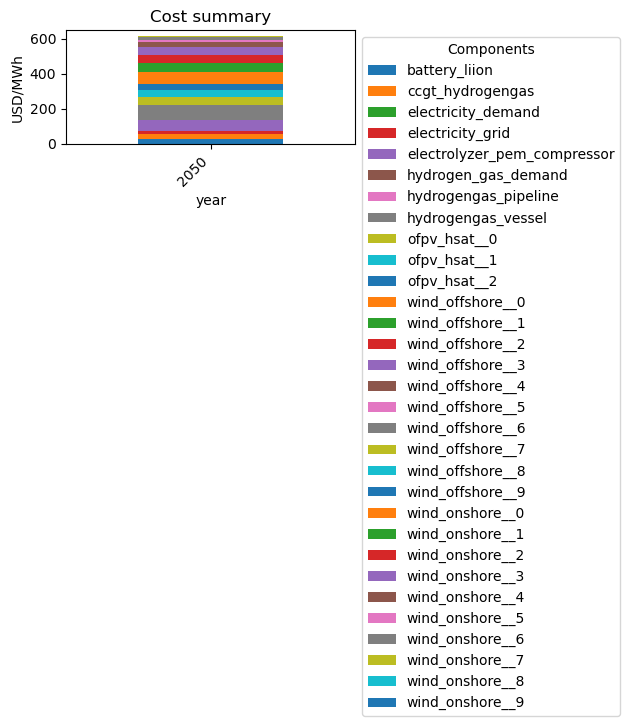

In [29]:
# ip
ip = 2050
cost_summary = cost_summary[cost_summary["year"]==ip]
# pivot for plot
cost_summary_pivot = cost_summary.pivot_table(index="year",columns="Component",values ="USD/MWh", aggfunc="sum")

# plot
cost_summary_pivot.plot(kind='bar', legend=False, stacked=True)

# labels
plt.title('Cost summary')
plt.ylabel('USD/MWh')

# layout
plt.xticks(rotation=45, ha='right')
plt.legend(title='Components', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.tight_layout()
plt.show()

(<Figure size 1200x400 with 1 Axes>,
 <Axes: xlabel='time step', ylabel='operation time series'>)

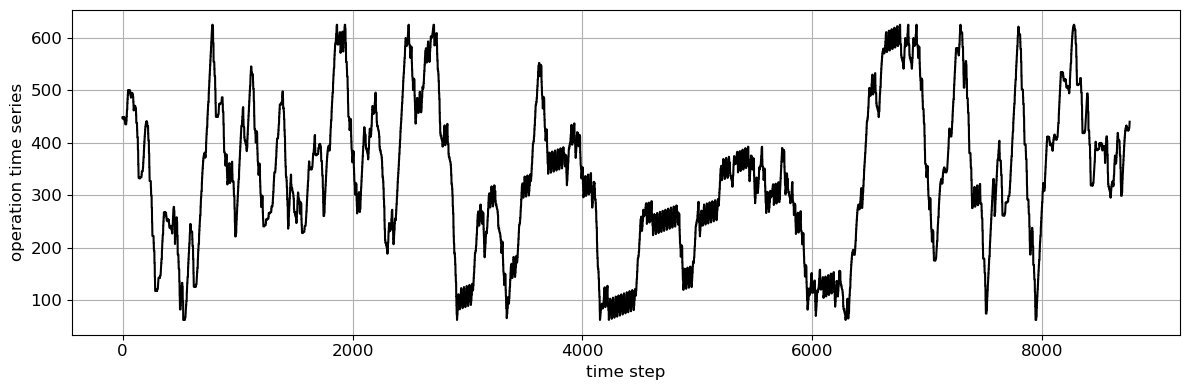

In [31]:
fn.plotOperation(esM=mb.esM, compName="hydrogengas_vessel",loc="DEU.10_1",ip=2050,variableName="stateOfChargeOperationVariablesOptimum")

(<Figure size 1200x400 with 1 Axes>,
 <Axes: xlabel='time step', ylabel='operation time series'>)

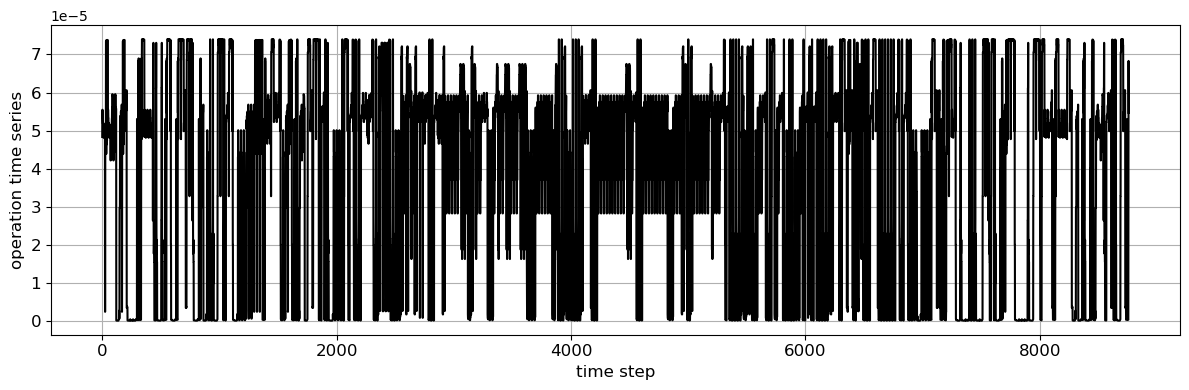

In [32]:
fn.plotOperation(esM=mb.esM, compName="electrolyzer_pem_compressor",loc="DEU.10_1",ip=2050)

(<Figure size 1200x400 with 1 Axes>,
 <Axes: xlabel='time step', ylabel='operation time series'>)

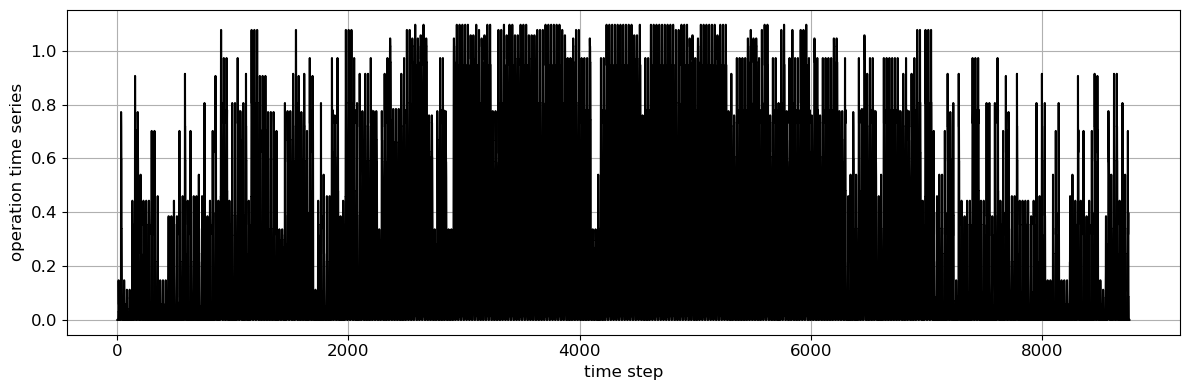

In [33]:
fn.plotOperation(esM=mb.esM, compName="ofpv_hsat__1",loc="DEU.10_1",ip=2050)

(<Figure size 1200x400 with 2 Axes>,
 <Axes: xlabel='period', ylabel='timestep per period'>)

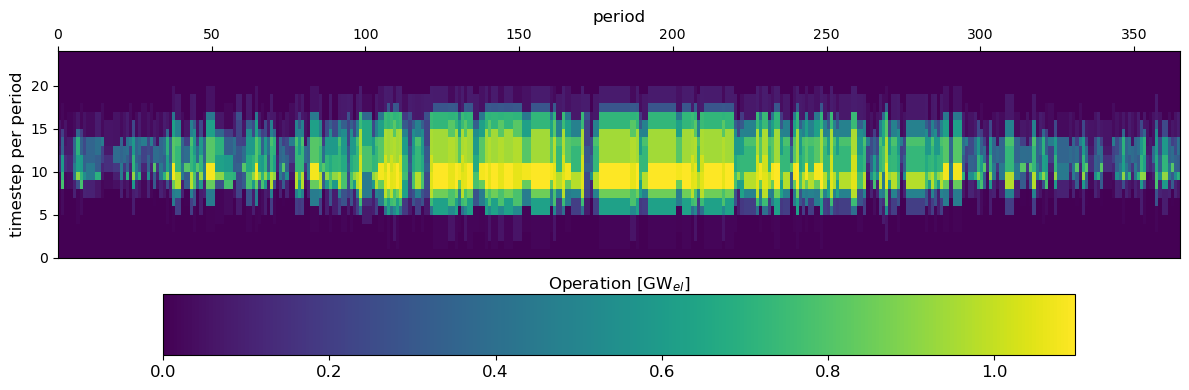

In [34]:
fn.plotOperationColorMap(esM=mb.esM, compName="ofpv_hsat__1",loc="DEU.10_1",ip=2050)

Plot Maps

In [35]:
# adjust shape coordinate system to file to PieChart 
intermediate_shape_crs3035 = gpd.read_file(intermediate_shape_fp).to_crs(3035)
intermediate_shape_crs3035.to_file("intermediate_shape_crs3035.shp")

In [36]:
mb.esM.componentNames.keys()


dict_keys(['electrolyzer_pem_compressor', 'ccgt_hydrogengas', 'electricity_demand', 'hydrogen_gas_demand', 'battery_liion', 'hydrogengas_vessel', 'electricity_grid', 'hydrogengas_pipeline', 'ofpv_hsat__0', 'ofpv_hsat__1', 'ofpv_hsat__2', 'wind_onshore__0', 'wind_onshore__1', 'wind_onshore__2', 'wind_onshore__3', 'wind_onshore__4', 'wind_onshore__5', 'wind_onshore__6', 'wind_onshore__7', 'wind_onshore__8', 'wind_onshore__9', 'wind_offshore__0', 'wind_offshore__1', 'wind_offshore__2', 'wind_offshore__3', 'wind_offshore__4', 'wind_offshore__5', 'wind_offshore__6', 'wind_offshore__7', 'wind_offshore__8', 'wind_offshore__9'])

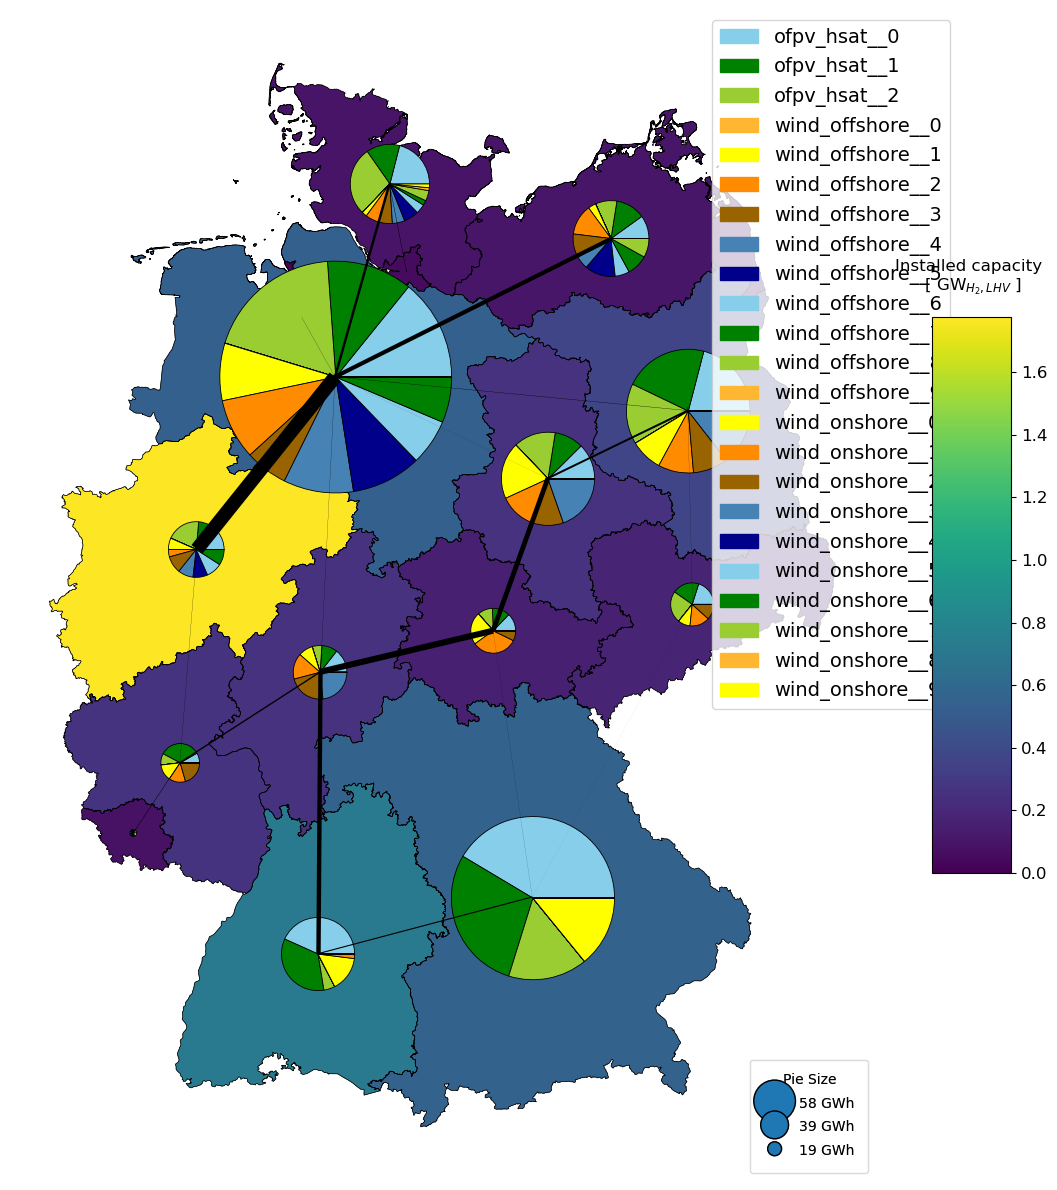

In [43]:
results_df = mb.esM.getOptimizationSummary("SourceSinkModel",ip=2050,outputLevel=1)

# make locColormap, PieChart, transmission 
fig, ax = fn.plotLocationalColorMap(esM=mb.esM, compName="hydrogen_gas_demand",variableName="operationVariablesOptimum",locationsShapeFileName=intermediate_shape_fp,indexColumn="GID_1",ip=2050, perArea=False,figsize=(12,12))
fig, ax, legend1 = plotPieChart(locFilePath="intermediate_shape_crs3035.shp",results_df=results_df,indexColumn_in_shp="GID_1", scaling_factor=120, fig=fig, ax=ax)
fig, ax = fn.plotTransmission(
    esM=mb.esM, compName="hydrogengas_pipeline",ip=2050, transmissionShapeFileName=os.path.join(ModelPaths().base_folder, "spatial_data", "transmissions.shp"),
    crs="EPSG:3035", loc0="bus_0", loc1="bus_1", fig=fig, ax=ax, color="black"
)

ax.add_artist(legend1)
max_cap = results_df.iloc[results_df.index.get_level_values("Property") == "capacity"].sum().max()
ax.add_artist(create_pie_size_legend(ax=ax, max_radius=160000, max_value=max_cap))

## 4. Storing results:

In [44]:
mb.saveToNC4()
print("saved", flush=True)

Save to nc4: /storage_cluster/projects/2022-a-burdack-phd/workspace/modelresults/testmodelbuilder_intermediates/esM_optimized.nc4

Writing output to netCDF... 


AttributeError: 'PowerDict' object has no attribute 'index'

## 5. Postprocessing

In [ ]:
postpro = outputDataHandler.OutputHandler(
    model_base_folder= model_base_folder,
    xr_dss=None,
    regions_shp=None,
    transmission_shp=None,
)

postpro.store_standard_evaluation()
postpro.store_default_plots()